<h1><center>Monitoring of sunspot groups ($N_g$)</center></h1> 

In [2]:
import pickle
import numpy as np 
import sys
sys.path.insert(0, '../Sunspot/')
sys.path.insert(1, '../')
from SunSpot import preprocessing
from SunSpot import CUSUM_design_BB as chart
from SunSpot import plot_performances as plot
from SunSpot import SVR_SVC_training as SVM
import matplotlib.pyplot as plt
from scipy.stats import iqr, skew, kurtosis
import warnings
warnings.simplefilter('ignore')

## Load and visualize data
* <h3> Load raw data (counts) and apply preprocessing </h3>

In [3]:
### load data
with open('../data/data_35_47', 'rb') as file:
     my_depickler = pickle.Unpickler(file)
     Ns = my_depickler.load() #number of spots
     Ng = my_depickler.load() #number of sunspot groups
     Nc = my_depickler.load() #Ns+10Ng
     station_names = my_depickler.load() #code names of the stations
     time = my_depickler.load() #time

In [4]:
### apply pre-processing
dataNg = preprocessing.PreProcessing(Ng, time, station_names) 

dataNg.rescaling(period_rescaling=14) #rescale Ns with respect to the median of the network
dataNg.commonSignalRemoval() #remove solar component
dataNg.movingAverage() #smooth the ratio (remove short-term error)
level = dataNg.ratio #long-term error with intrinsic levels (mu2) 
dataNg.levelRemoval(wdw=420) #remove intrisic levels
dataNg.selectionIC(method='fixed', nIC1=10, nIC2=6) #select P1 and P2
IC_stations = dataNg.pool #P1
dataNg.outliersRemoval() #adaptive shewhart (remove deviations in P1 and P2)
dataNg.standardisation() #standardization
data = dataNg.data #data with deviations
dataIC = dataNg.dataIC #IC data (P1), without deviations

pool = ([station_names[i] for i in range(len(station_names)) if i in IC_stations])
print("pool:", pool)

P1 containing  10 stations
P2 containing  6 stations
pool: ['A3', 'CA', 'FU', 'HU', 'KH', 'KOm', 'KS2', 'KZm', 'MO', 'UC']


* <h3> Or directyl load preprocessed data </h3>

In [3]:
with open('../data/Ng', 'rb') as file:     
     my_depickler = pickle.Unpickler(file)
     data = my_depickler.load() #data with deviations
     time = my_depickler.load() #time
     station_names = my_depickler.load() #code names of the stations
     dataIC = my_depickler.load() #IC stations without deviations
     IC_stations = my_depickler.load() #indexes of IC stations (P1)
     level = my_depickler.load() #long-term error with intrinsic levels (mu2)

(n_obs, n_series) = data.shape #dimensions 


<h3> Plot the residuals distribution </h3>

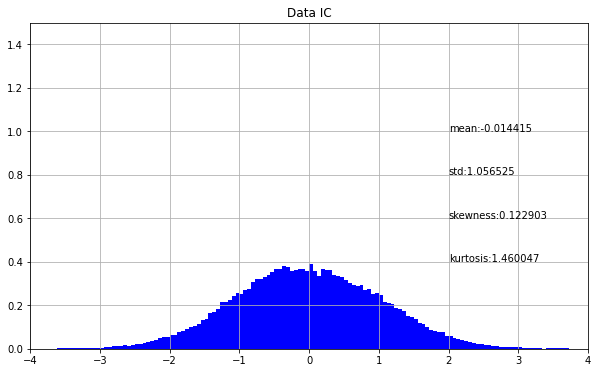

In [12]:
plt.rcParams['figure.figsize'] = (10.0, 6.0)
plt.figure(1)  
plt.hist(dataIC[~np.isnan(dataIC)], range=[-4,4], bins='auto', density=True, facecolor='b')  
plt.title("Data IC")
plt.text(2, 1, 'mean:' '%4f' %np.nanmean(dataIC))
plt.text(2, 0.8, 'std:' '%4f' %np.nanstd(dataIC))
plt.text(2, 0.6, 'skewness:' '%4f' %skew(dataIC[~np.isnan(dataIC)]))
plt.text(2, 0.4, 'kurtosis:' '%4f' %kurtosis(dataIC[~np.isnan(dataIC)]))
plt.axis([-4, 4, 0, 1.5])
plt.grid(True)
plt.show()

## Design of the CUSUM chart

<h3> Set the parameters</h3>

In [5]:
delta_min = 1.5 #min shift size to detect
BBL = 27 #block length 
k = delta_min/2 #allowance parameter
ARL0 = 200 #pre-specified ARL0

<h3>Adjust the control limit of the chart.</h3>
<p>Since the results may vary (block bootstrap procedure), we may obtain different results from one run to another. </p>

In [17]:
L = chart.search_CUSUM_MV(dataIC, delta=delta_min, ARL0_threshold=ARL0, block_length=BBL, missing_values='reset') #8.125


252.32062532661976
5.0
94.52660053156146
7.5
156.61999172083654
8.75
200.49154501670134
8.125


<h3> Compute the performance (ARL1 value) of the chart</h3>

In [19]:
ARL1 = chart.ARL1_CUSUM_MV(dataIC, L, delta=delta_min, missing_values='reset', block_length=BBL) #40
print(ARL1)

40.42444879726087


## Train and validate the classifier and regressor

<h3>Set the parameters</h3>

In [7]:
n = 21000*3 #number of testing and training instances
scale = 3.5 #scale parameter of the halfnormal distribution

<h3>Compute the control limit in absence of missing values (the simulations do not contain missing values)</h3>

In [21]:
L_wht_MV = chart.search_CUSUM_MV(dataIC, delta=delta_min, ARL0_threshold=ARL0, verbose=True, block_length=BBL) #10.3

189.64476218410184
15.0
400.4074921314322
12.5
277.09883827389757
11.25
232.04949414545356
10.625
210.34141880110317
10.3125
204.49936697586674
10.15625
195.1622204092132
10.234375
192.37249735708838
10.2734375
195.31387558601017
10.29296875
198.93707422093874
10.302734375


<h3>Select the length of the input vector</h3>

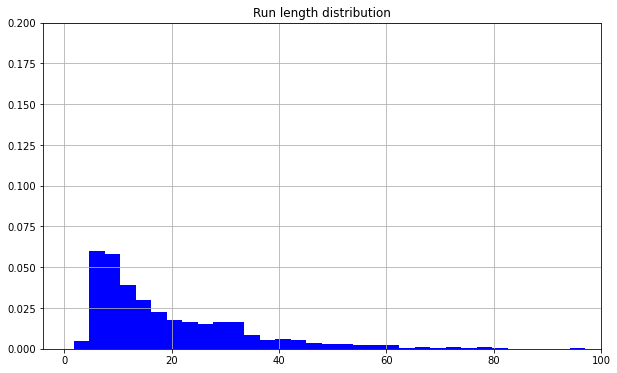

24


In [23]:
wdw_length = SVM.selection_input_vector(dataIC, delta_min, L_wht_MV, BBL) # 24  
print(wdw_length)

<h3>Train and validate the models</h3>

MAPE= 25.10282847280964
NRMSE= 0.2447390058742007
Accuracy= 85.96031746031746
MAE= 0.19944444444444445
MSE= 0.31753968253968257
Confusion matrix, without normalization
[[3506  205  489]
 [ 284 3602  314]
 [ 255  222 3723]]
Normalized confusion matrix
[[0.8347619  0.04880952 0.11642857]
 [0.06761905 0.85761905 0.0747619 ]
 [0.06071429 0.05285714 0.88642857]]


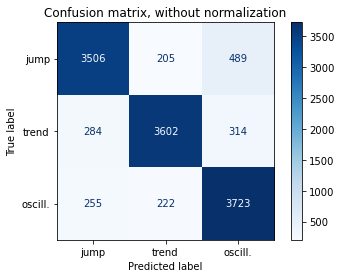

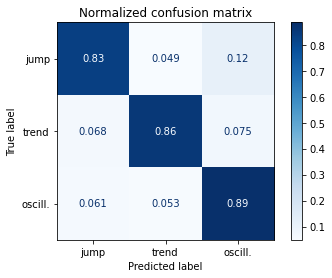

In [9]:
reg, clf = SVM.training_svr_svm(dataIC, L_wht_MV, delta_min, n, wdw_length, scale, BBL)

### save models 
#filename = 'svr_Ng.sav'
#pickle.dump(reg, open(filename, 'wb'))
#filename = 'svc_Ng.sav'
#pickle.dump(clf, open(filename, 'wb'))

<h3>Or directly load trained models, for reproduciability purpose</h3>

In [6]:
reg = pickle.load(open('../models/svr_Ng.sav', 'rb'))
clf = pickle.load(open('../models/svc_Ng.sav', 'rb'))
wdw_length = 24

## Run the control chart and show the performance results

51.032665964172814


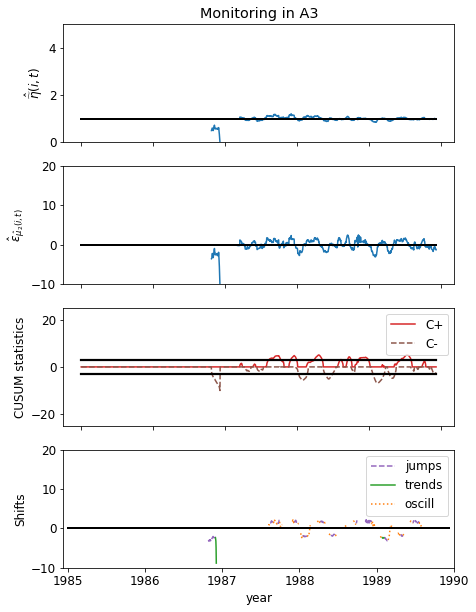

81.99217658563845


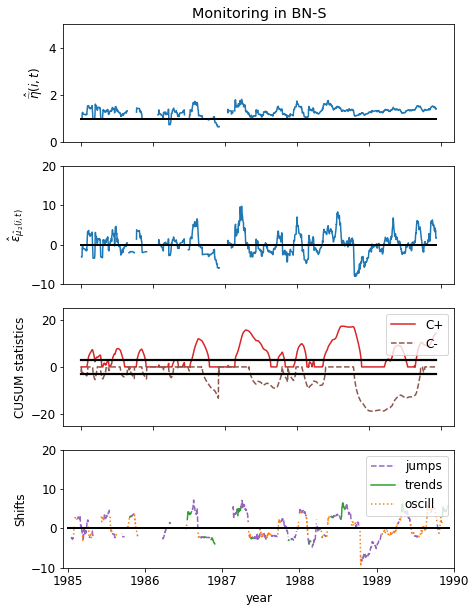

59.168314656119534


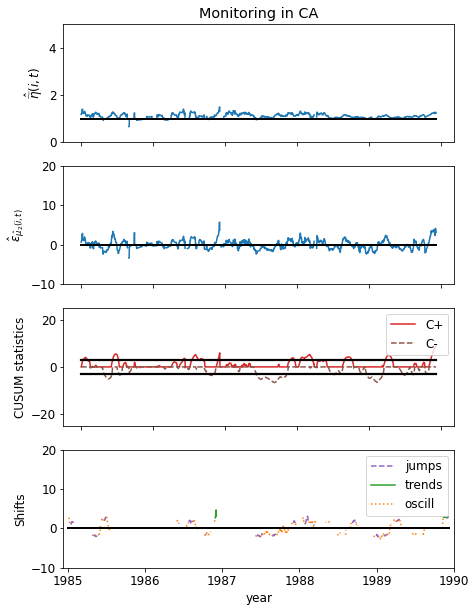

78.40640770406037


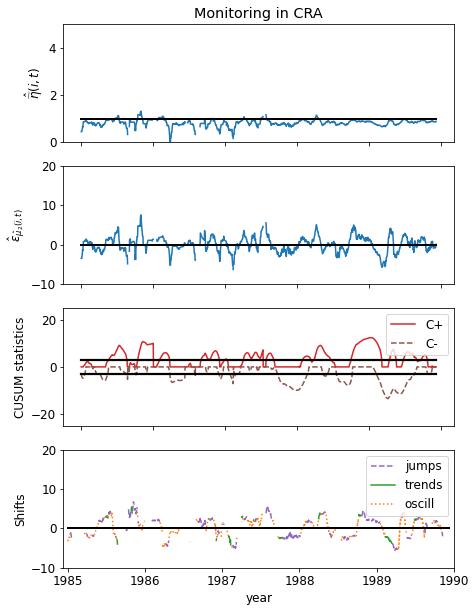

44.49291856348002


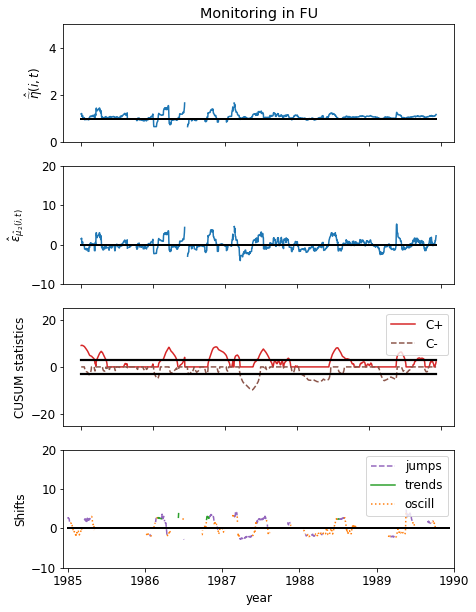

78.75631796599785


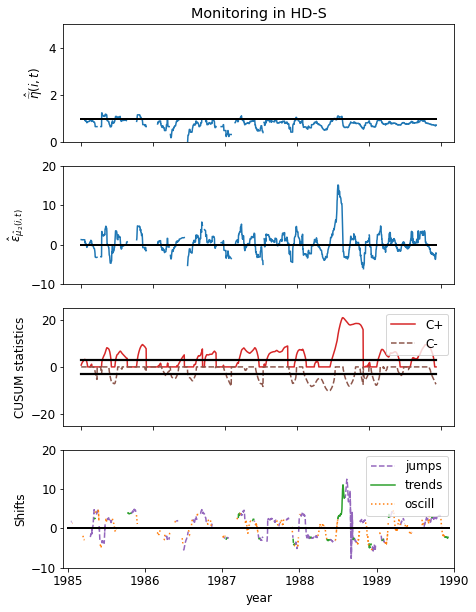

58.309520228605805


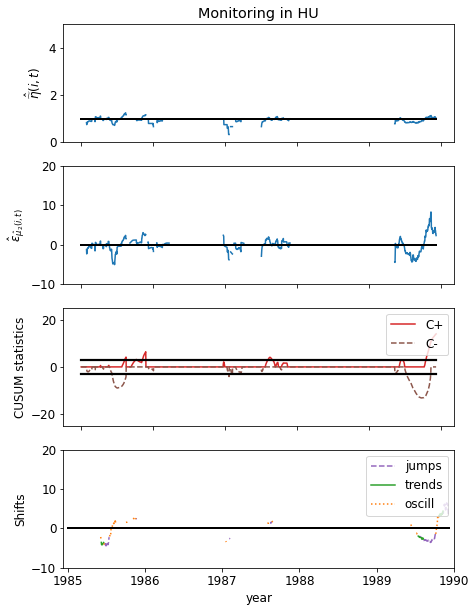

54.51348182883939


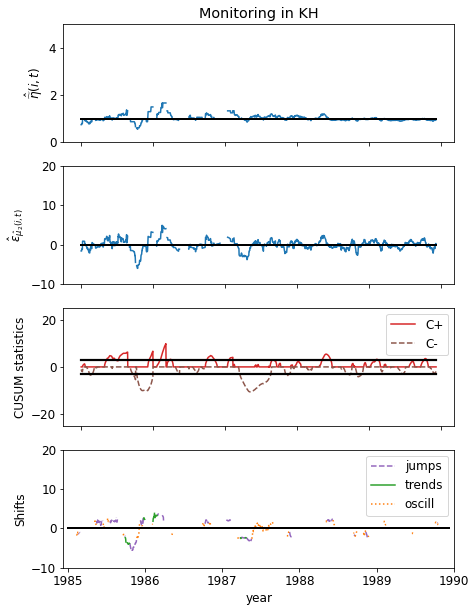

70.44097381717961


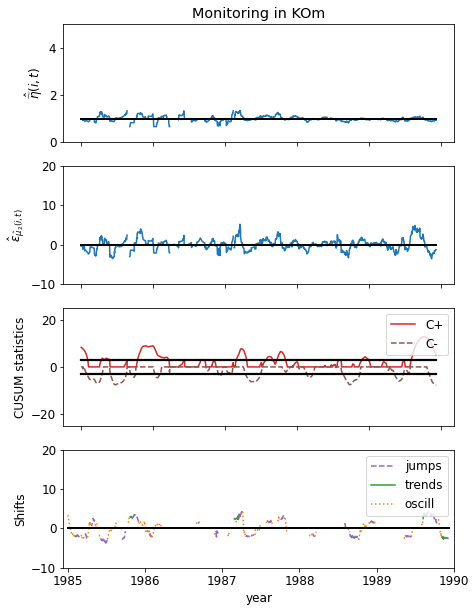

75.01167242506303


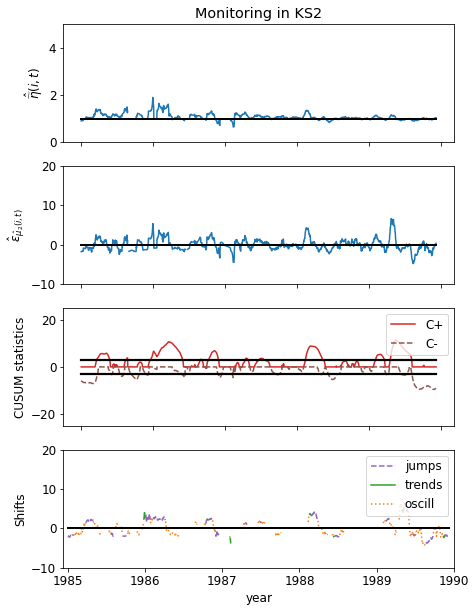

60.75073664431823


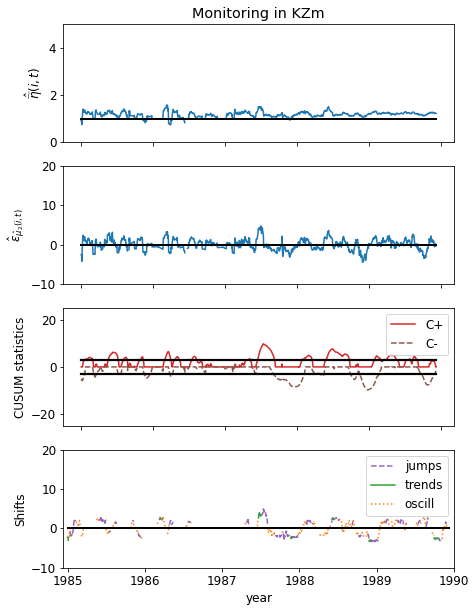

74.53440349099976


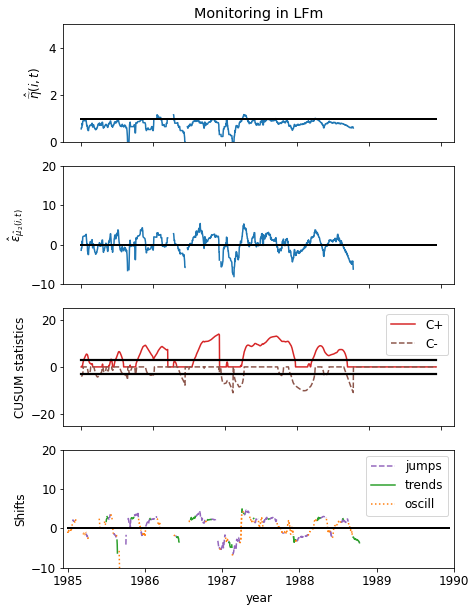

82.65673305965232


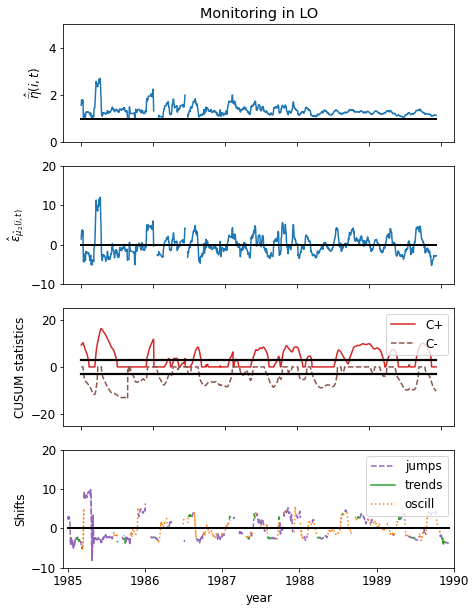

72.49015748031496


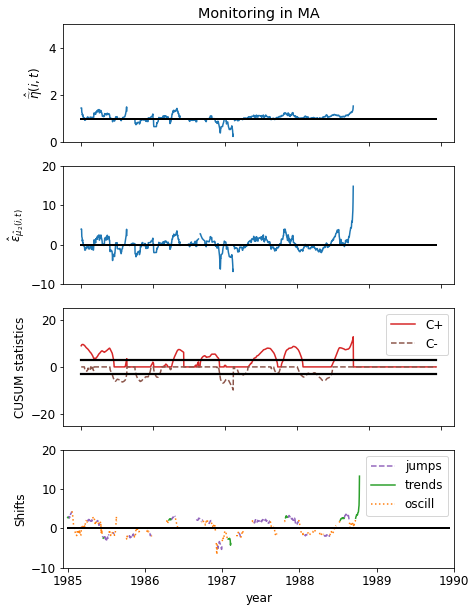

68.7980574666127


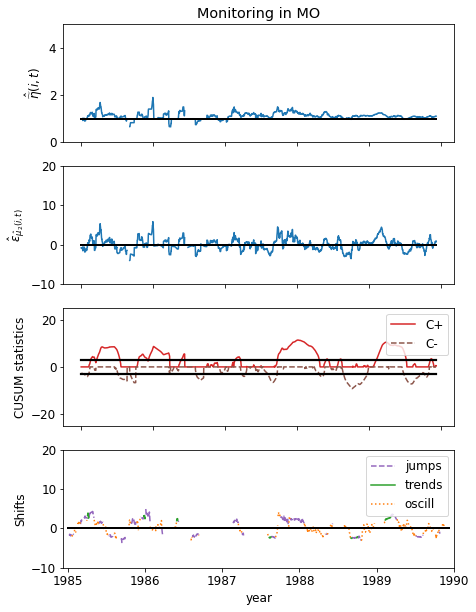

73.69240859157239


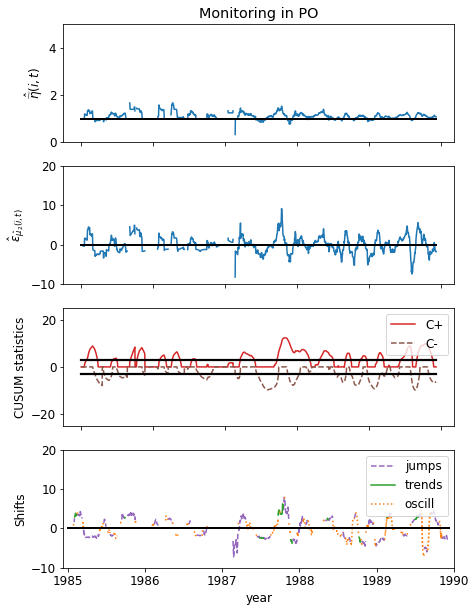

79.33703726824396


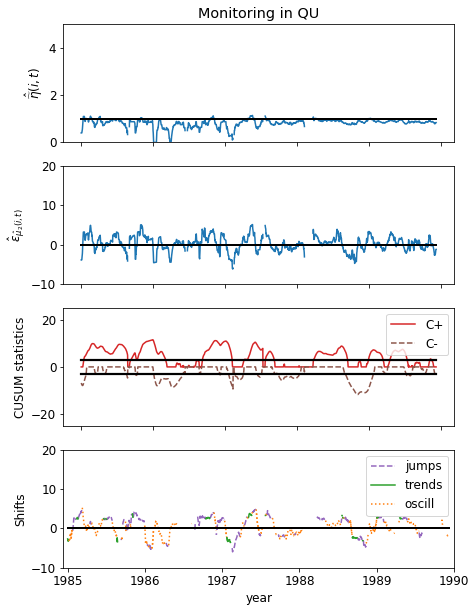

73.0821695355635


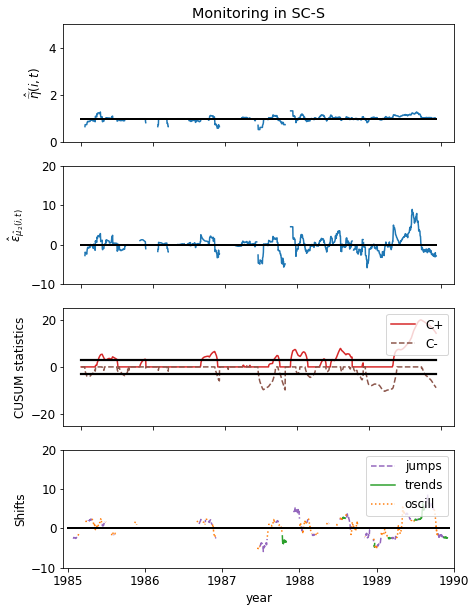

81.14240525579415


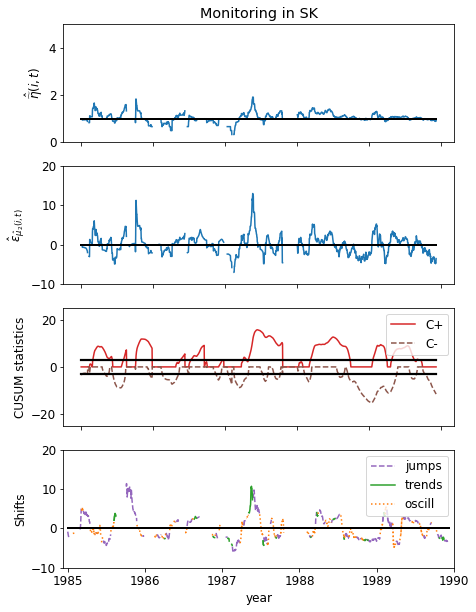

79.30423367246472


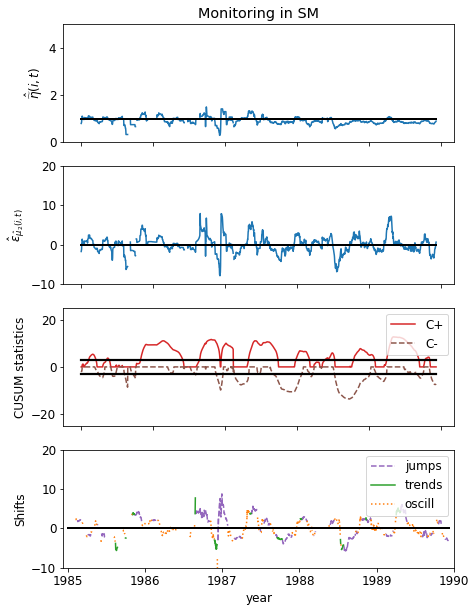

74.9387380028589


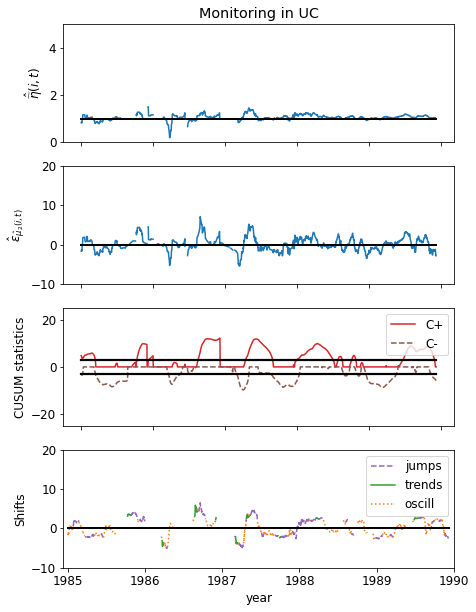

In [10]:
start = int(np.where(time == 1985)[0]) #start of the period (plot)
length = 1800 #length of the period (plot)

for i in range(n_series): 
    data_indv = data[:,i]
    level_indv = level[:,i]
    
    [form_plus, form_minus, size_plus, size_minus,
    C_plus, C_minus] = plot.CUSUM_monitoring(data_indv, L, delta_min, wdw_length, clf, reg)
    
    fig = plot.plot_performances(data_indv, level_indv, L, time, form_plus, form_minus, size_plus, 
                          size_minus, C_plus, C_minus, station_names[i], start, length)
        
        